# Linear Regression Business Assignment

## Problem 1: Delivery Time Prediction

Objective:
Predict delivery time based on sorting time using Linear Regression.

Business Goal:
- Improve delivery SLA
- Optimize warehouse operations
- Reduce customer complaints

In [86]:
####import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [22]:
##load file
file = "C:/Users/Admin/Documents/ASSIGNMENTS/delivery_time.csv"
data = pd.read_csv(file)
data.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [23]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 468.0 bytes


,Delivery Time,Sorting Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


In [24]:
data.isna().sum()

Delivery Time    0
Sorting Time     0
dtype: int64

In [38]:
data.shape

(21, 2)

In [37]:
data.rename(columns = {'Delivery Time': 'Delivery_Time','Sorting Time':'Sorting_Time'}, inplace=True)
data.columns

Index(['Delivery_Time', 'Sorting_Time'], dtype='object')

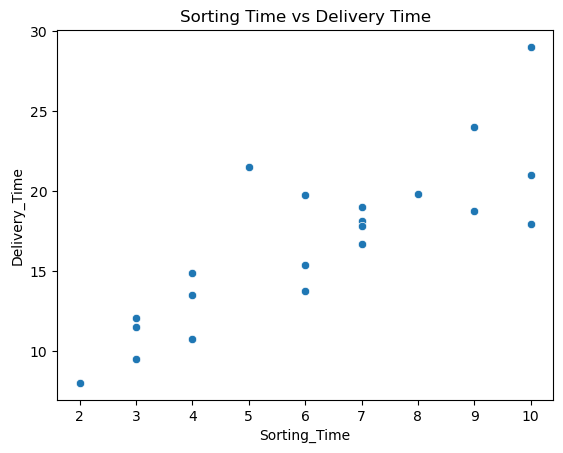

In [35]:
##visualize relationship
sns.scatterplot(x='Sorting_Time', y='Delivery_Time', data=data)
plt.title("Sorting Time vs Delivery Time")
plt.show()

## Observation from Scatter Plot

- There is a positive relationship between Sorting Time and Delivery Time.
- As sorting time increases, delivery time also increases.
- The data points show a roughly linear pattern.
- There are no significant outliers present.
- Hence, Simple Linear Regression is suitable for this dataset.

In [41]:
###split X and y, training data
X = data[['Sorting_Time']]
y = data['Delivery_Time']

model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
##prediction 
y_pred = model.predict(X)
y_pred

array([23.07293294, 13.17881356, 16.47685335, 21.42391304, 23.07293294,
       16.47685335, 18.12587325, 11.52979366, 23.07293294, 21.42391304,
       19.77489315, 13.17881356, 18.12587325, 11.52979366, 11.52979366,
       13.17881356, 16.47685335, 18.12587325,  9.88077377, 18.12587325,
       14.82783346])

In [48]:
##comparision of actual and predicted data
df = pd.DataFrame({'actual': y, 'predicted': y_pred})
df

,actual,predicted
0,21.00,23.072933
1,13.50,13.178814
2,19.75,16.476853
3,24.00,21.423913
4,29.00,23.072933
5,15.35,16.476853
6,19.00,18.125873
7,9.50,11.529794
8,17.90,23.072933
9,18.75,21.423913


In [63]:
##evaluation
print('r2score:' ,r2_score(y,y_pred))

r2score: 0.6822714748417231


## Model Evaluation

- The R² score of the model is 0.682.
- This means that approximately 68.2% of the variation in delivery time is explained by sorting time.
- The model shows a reasonably good fit but is not perfect.
- There are other factors affecting delivery time that are not included in the model.
- Hence, the model can be used for prediction but with moderate accuracy.

In [92]:
##model transformation
#Log Transformation
#transform X
X_log = np.log(data[['Sorting_Time']])

In [93]:
##build model
model_log = LinearRegression()
model_log.fit(X_log, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
##prediction
y_pred_log = model_log.predict(X_log)

##evaluation
print('r2 Log Model :', r2_score(y,y_pred_log))

r2 Log Model : 0.6954434611324223


In [95]:
###Square Root Transformation
#transform X
X_sqrt = np.sqrt(data[['Sorting_Time']])

In [96]:
##build model
model_sqrt = LinearRegression()
model_sqrt.fit(X_log, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [97]:
##prediction
y_pred_sqrt = model_sqrt.predict(X_sqrt)

##evaluation
print('r2 Sqrt Model :', r2_score(y,y_pred_sqrt))

r2 Sqrt Model : -0.9727636429029809


In [98]:
####compare all models
print('r2score:' ,r2_score(y,y_pred))
print('r2 Log Model :', r2_score(y,y_pred_log))
print('r2 Sqrt Model :', r2_score(y,y_pred_sqrt))

r2score: 0.6822714748417231
r2 Log Model : 0.6954434611324223
r2 Sqrt Model : -0.9727636429029809


## Model Comparison and Final Selection

- The original model gave an R² score of 0.682.
- After applying Log transformation, the R² improved to 0.695, indicating a better model fit.
- However, the Square Root transformation resulted in a negative R² score (-0.973), indicating a very poor model performance.

## Final Model Selection

- The Log transformation model is selected as the final model as it provides the highest R² score.
- This indicates that applying a logarithmic transformation improves the relationship between sorting time and delivery time.

## Conclusion

- There is a positive relationship between Sorting Time and Delivery Time.
- As sorting time increases, delivery time also increases.
- The final model provides a reasonably good prediction with an R² score of 0.695.
- The poor performance of the square root model suggests that not all transformations improve model performance.
- Other external factors may also influence delivery time, which are not included in this model.

In [99]:
##create new data
new_data = pd.DataFrame({'Sorting_Time': [5, 10, 15]})

# using LOG model predict
pred = model_log.predict(np.log(new_data))
print(pred)

[15.71449599 21.98291253 25.64970115]


In [100]:
##combine results
output = new_data.copy()
output['Predicted_Delivery_Time'] = pred
output

,Sorting_Time,Predicted_Delivery_Time
0,5,15.714496
1,10,21.982913
2,15,25.649701


In [101]:
###save output
output.to_csv("C:/Users/Admin/Documents/Problem1_Predictions.csv", index=False)